# 03 — Origin Classification with Static Word Embeddings

Mirrors the 02 TF-IDF workflow using static word embeddings (GloVe / Word2Vec / fastText) instead of sparse lexical features. Same filtering, same split, same resampling framework — only the feature extractor changes — so the comparison against 02 is apples-to-apples.

Main steps:

1. Load and filter to classes with ≥30 samples
2. Build preprocessing variants
3. Stratified 70/15/15 split
4. Grid search over preprocessing × embedding × classifier, selected on validation Macro-F1
5. Best-model test evaluation and confusion matrix
6. Training-only resampling experiments

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec, FastText
import gensim.downloader as api

from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


## Load and filter the dataset

In [2]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(2)

Shape: (7585, 30)


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country,aroma_text,flavor_text,acidity_text,body_text,combined_text
0,https://www.coffeereview.com/review/100-arabic...,87\nCaribeans\n100% Arabica Coffee from Puerto...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,NaN,Satisfying chocolate and nut notes nearly carr...,7.0,Puerto Rico; China,Puerto Rico,NaN,"bittersweet but balanced dark chocolate, dried...","bittersweet but balanced brisk, dry acidity",smooth but rather lean mouthfeel,"bittersweet but balanced dark chocolate, dried..."
1,https://www.coffeereview.com/review/100-arabic...,88\nWaka Coffee\n100% Arabica Freeze-Dried Col...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,NaN,A appealing 100% Colombia coffee in instant fo...,7.0,Colombia,Colombia,NaN,"caramel-toned, richly sweet dark caramel, magn...",sweet-toned in structure with brisk acidity,smooth mouthfeel,"caramel-toned, richly sweet dark caramel, magn..."


In [3]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

coffee_terms_to_keep = {
    'acid', 'acidity', 'aromatic', 'berry', 'bright', 'buttery', 'caramel', 'cherry',
    'chocolate', 'citrus', 'clean', 'cocoa', 'creamy', 'crisp', 'dark', 'drying',
    'earthy', 'finish', 'flavor', 'floral', 'flower', 'fruit', 'fruity', 'honey',
    'jasmine', 'juicy', 'lemon', 'lime', 'mouthfeel', 'nectarine', 'nut', 'nutty',
    'orange', 'peach', 'rose', 'round', 'silky', 'smooth', 'spice', 'spicy', 'stone',
    'sweet', 'syrupy', 'tangerine', 'tea', 'tone', 'vanilla', 'winey'
}
stop_words = set(ENGLISH_STOP_WORDS) - coffee_terms_to_keep

misspelling_replacements = {
    r'\bchocolaty\b': 'chocolate',
    r'\bchoclate\b': 'chocolate',
    r'\bcitrussy\b': 'citrus',
    r'\bcitricy\b': 'citrus',
    r'\bcaramelly\b': 'caramel',
    r'\bcarmel\b': 'caramel',
    r'\bflorals\b': 'floral',
    r'\bfruity\b': 'fruit',
    r'\bnutty\b': 'nut',
    r'\bberries\b': 'berry',
}

phrase_replacements = {
    r'\bdark\s+chocolate\b': 'dark_chocolate',
    r'\bmilk\s+chocolate\b': 'milk_chocolate',
    r'\bbaking\s+chocolate\b': 'baking_chocolate',
    r'\bstone\s+fruit\b': 'stone_fruit',
    r'\borange\s+zest\b': 'orange_zest',
    r'\blemon\s+zest\b': 'lemon_zest',
    r'\bbrown\s+sugar\b': 'brown_sugar',
    r'\bred\s+apple\b': 'red_apple',
    r'\bpipe\s+tobacco\b': 'pipe_tobacco',
    r'\baromatic\s+wood\b': 'aromatic_wood',
    r'\btea\s+rose\b': 'tea_rose',
    r'\bdried\s+berry\b': 'dried_berry',
    r'\bchocolatey\b': 'chocolate',
    r'\bcocoa\s+toned\b': 'cocoa',
    r'\bcitrusy\b': 'citrus',
    r'\bberry\s+like\b': 'berry',
    r'\bberrylike\b': 'berry',
    r'\bfruit\s+toned\b': 'fruit',
    r'\bfloral\s+toned\b': 'floral',
    r'\bnut\s+toned\b': 'nut',
    r'\bcaramel\s+like\b': 'caramel',
    r'\bsweet\s+toned\b': 'sweet',
}

strip_punct_table = str.maketrans('', '', string.punctuation.replace('_', ''))


def minimal_raw_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def apply_replacements(text: str) -> str:
    for pattern, replacement in misspelling_replacements.items():
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in phrase_replacements.items():
        text = re.sub(pattern, replacement, text)
    return text


def normalize_text(text: str) -> str:
    text = minimal_raw_text(text).lower()
    text = apply_replacements(text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def remove_domain_stopwords(text: str) -> str:
    tokens = [token for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_stem(text: str) -> str:
    tokens = [stemmer.stem(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_lemmatize(text: str) -> str:
    tokens = [lemmatizer.lemmatize(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def tokenize_text(text: str):
    return [token for token in text.split() if len(token.strip()) > 1]


## Build preprocessing variants

In [4]:
# Build text input variants for preprocessing ablation
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)
df['text_domain_stopwords'] = df['text_basic'].map(remove_domain_stopwords)
df['text_domain_stopwords_stemmed'] = df['text_basic'].map(remove_domain_stopwords_and_stem)
df['text_domain_stopwords_lemmatized'] = df['text_basic'].map(remove_domain_stopwords_and_lemmatize)
df['text_main'] = df['text_basic']

# Use the country label prepared in notebook 01
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

# Keep valid rows only
work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()

# Remove tiny classes for a stable baseline
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()

print('Rows after filtering:', len(work))
print('Num classes:', work['origin_country'].nunique())
work['origin_country'].value_counts().head(15)


Rows after filtering: 6820
Num classes: 15


origin_country
Ethiopia         1996
Colombia          988
Kenya             699
Guatemala         561
Indonesia         452
Costa Rica        373
Panama            354
United States     302
El Salvador       240
Brazil            200
Rwanda            176
Peru              130
Nicaragua         125
Honduras          123
Mexico            101
Name: count, dtype: Int64

## Dataset summary and class distribution

In [5]:
dataset_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after preprocessing/filtering',
        'Unique origin classes after filtering',
        'Minimum samples per class',
        'Review date min',
        'Review date max',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
        df['Review Date'].min(),
        df['Review Date'].max(),
    ]
})

dataset_summary

,metric,value
0,Rows in raw dataset,7585
1,Rows after preprocessing/filtering,6820
2,Unique origin classes after filtering,15
3,Minimum samples per class,100
4,Review date min,1997-02-01
5,Review date max,2026-03-01


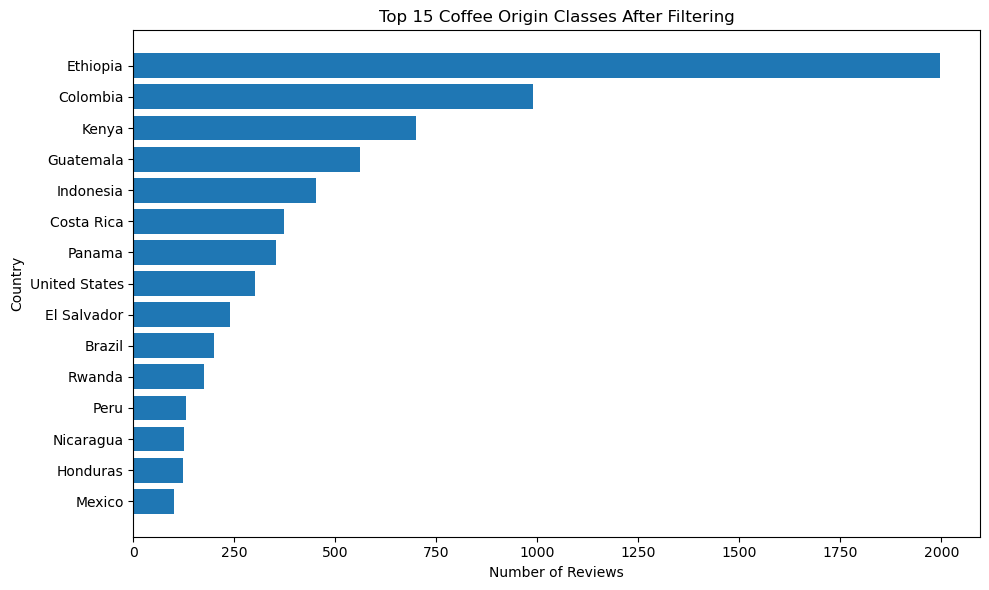

In [6]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(origin_counts.index, origin_counts.values)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.title('Top 15 Coffee Origin Classes After Filtering')
plt.tight_layout()
plt.show()

## Stratified 70/15/15 split

In [7]:
work = work.reset_index(drop=True)
y = work['origin_country']
row_idx = work.index

# 70/15/15 split (stratified)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train:', len(train_idx), 'Val:', len(val_idx), 'Test:', len(test_idx))

Train: 4774 Val: 1023 Test: 1023


## Evaluation helper

In [8]:
def evaluate_predictions(y_true, y_pred, split_name='split'):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f'== {split_name} ==')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Balanced Accuracy: {bal_acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall:    {r:.4f}')
    print(f'F1-macro:  {f1:.4f}')
    return acc, bal_acc, p, r, f1


def build_idf_map(train_texts):
    vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), min_df=2, max_df=0.95)
    vec.fit(train_texts)
    return dict(zip(vec.get_feature_names_out(), vec.idf_))


def lookup_vector(token, kv):
    candidates = [
        token,
        token.lower(),
        token.strip(string.punctuation),
        token.lower().strip(string.punctuation),
    ]
    for candidate in candidates:
        if candidate and candidate in kv.key_to_index:
            return kv[candidate]
    return None


def docs_to_weighted_vectors(token_docs, kv, idf_map, vector_size=100):
    X = np.zeros((len(token_docs), vector_size), dtype=np.float32)
    for i, tokens in enumerate(token_docs):
        weighted_vecs = []
        weights = []
        for token in tokens:
            vec = lookup_vector(token, kv)
            if vec is not None:
                clean_token = token.lower().strip(string.punctuation)
                weight = idf_map.get(clean_token, idf_map.get(token, 1.0))
                weighted_vecs.append(vec * weight)
                weights.append(weight)
        if weights:
            X[i] = np.sum(weighted_vecs, axis=0) / np.sum(weights)
    return X


glove_kv = None
try:
    glove_kv = api.load('glove-wiki-gigaword-100')
    print('Loaded GloVe: glove-wiki-gigaword-100')
except Exception as e:
    print('Could not load GloVe. GloVe experiments will be skipped.')
    print('Reason:', e)


def build_embedding_kv(embedding_name, train_token_docs):
    if embedding_name == 'Word2Vec':
        model = Word2Vec(
            sentences=train_token_docs,
            vector_size=VECTOR_SIZE,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=1,
            seed=RANDOM_STATE,
        )
        return model.wv
    if embedding_name == 'fastText':
        model = FastText(
            sentences=train_token_docs,
            vector_size=VECTOR_SIZE,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=1,
            seed=RANDOM_STATE,
        )
        return model.wv
    if embedding_name == 'GloVe':
        return glove_kv
    raise ValueError(f'Unknown embedding: {embedding_name}')


def build_classifier(model_name, c_value, feature_reduction='none'):
    steps = [('scaler', StandardScaler())]
    if feature_reduction == 'pca_50':
        steps.append(('pca', PCA(n_components=50, random_state=RANDOM_STATE)))

    if model_name == 'Logistic Regression':
        steps.append(('clf', LogisticRegression(
            C=c_value,
            max_iter=5000,
            solver='liblinear',
            class_weight='balanced',
            multi_class='ovr',
            random_state=RANDOM_STATE,
        )))
        return Pipeline(steps)
    if model_name == 'Linear SVM':
        steps.append(('clf', LinearSVC(
            C=c_value,
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )))
        return Pipeline(steps)
    raise ValueError(f'Unknown classifier: {model_name}')


def vectorize_embedding_split(embedding_name, train_texts, val_texts, test_texts):
    train_tokens = [tokenize_text(text) for text in train_texts]
    val_tokens = [tokenize_text(text) for text in val_texts]
    test_tokens = [tokenize_text(text) for text in test_texts]
    kv = build_embedding_kv(embedding_name, train_tokens)
    if kv is None:
        return None
    idf_map = build_idf_map(train_texts)
    X_train_vec = docs_to_weighted_vectors(train_tokens, kv, idf_map, VECTOR_SIZE)
    X_val_vec = docs_to_weighted_vectors(val_tokens, kv, idf_map, VECTOR_SIZE)
    X_test_vec = docs_to_weighted_vectors(test_tokens, kv, idf_map, VECTOR_SIZE)
    return X_train_vec, X_val_vec, X_test_vec


Loaded GloVe: glove-wiki-gigaword-100


## Hyperparameter grid: preprocessing × embedding × classifier

In [9]:
preprocessing_variants = {
    'Raw text / punctuation preserved': 'text_raw_minimal',
    'Basic normalization': 'text_basic',
    'Domain stopword removal': 'text_domain_stopwords',
    'Domain stopword removal + stemming': 'text_domain_stopwords_stemmed',
    'Domain stopword removal + lemmatization': 'text_domain_stopwords_lemmatized',
}

ablation_results = []
best_preprocessing_name = None
best_text_column = None
best_preprocessing_val_f1 = -1

for variant_name, column_name in preprocessing_variants.items():
    train_texts = work.loc[train_idx, column_name].tolist()
    val_texts = work.loc[val_idx, column_name].tolist()
    test_texts = work.loc[test_idx, column_name].tolist()
    vectors = vectorize_embedding_split('Word2Vec', train_texts, val_texts, test_texts)
    if vectors is None:
        continue
    X_train_vec, X_val_vec, X_test_vec = vectors
    ablation_model = build_classifier('Linear SVM', 1.0, feature_reduction='none')
    ablation_model.fit(X_train_vec, y_train)
    y_val_pred = ablation_model.predict(X_val_vec)
    y_test_pred = ablation_model.predict(X_test_vec)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)

    ablation_results.append({
        'preprocessing_variant': variant_name,
        'text_column': column_name,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    })

    if val_f1 > best_preprocessing_val_f1:
        best_preprocessing_val_f1 = val_f1
        best_preprocessing_name = variant_name
        best_text_column = column_name

ablation_results_df = pd.DataFrame(ablation_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print('Selected preprocessing variant:', best_preprocessing_name)
print('Selected text column:', best_text_column)
ablation_results_df


Selected preprocessing variant: Domain stopword removal + lemmatization
Selected text column: text_domain_stopwords_lemmatized


,preprocessing_variant,text_column,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Domain stopword removal + lemmatization,text_domain_stopwords_lemmatized,0.246334,0.185860,0.171633,0.185860,0.155234,0.251222,0.196377,0.172596,0.196377,0.159863
1,Basic normalization,text_basic,0.229717,0.192135,0.158667,0.192135,0.154409,0.235582,0.176829,0.176446,0.176829,0.155230
2,Domain stopword removal + stemming,text_domain_stopwords_stemmed,0.230694,0.189696,0.160619,0.189696,0.151140,0.225806,0.169783,0.152523,0.169783,0.138839
3,Domain stopword removal,text_domain_stopwords,0.233627,0.179462,0.159218,0.179462,0.145670,0.232649,0.171425,0.177213,0.171425,0.150722
4,Raw text / punctuation preserved,text_raw_minimal,0.212121,0.164504,0.166717,0.164504,0.140239,0.219941,0.187401,0.154555,0.187401,0.143518


In [10]:
X_train = work.loc[train_idx, best_text_column].tolist()
X_val = work.loc[val_idx, best_text_column].tolist()
X_test = work.loc[test_idx, best_text_column].tolist()

embedding_names = ['Word2Vec', 'fastText']
if glove_kv is not None:
    embedding_names.append('GloVe')

search_space = [
    {
        'embedding_name': embedding_names,
        'model_name': ['Logistic Regression', 'Linear SVM'],
        'C': [1, 5],
        'feature_reduction': ['none', 'pca_50'],
    }
]

search_results = []
best_model = None
best_params = None
best_val_f1 = -1
print('Total tuned configurations:', sum(len(list(ParameterGrid(grid))) for grid in search_space))

vector_cache = {}
for emb_name in embedding_names:
    vector_cache[emb_name] = vectorize_embedding_split(emb_name, X_train, X_val, X_test)

for grid in search_space:
    for params in ParameterGrid(grid):
        vectors = vector_cache.get(params['embedding_name'])
        if vectors is None:
            continue
        X_train_vec, X_val_vec, X_test_vec = vectors
        model = build_classifier(params['model_name'], params['C'], params['feature_reduction'])
        model.fit(X_train_vec, y_train)
        y_val_pred = model.predict(X_val_vec)
        val_acc = accuracy_score(y_val, y_val_pred)
        val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)

        row = dict(params)
        row['val_accuracy'] = val_acc
        row['val_balanced_accuracy'] = val_bal_acc
        row['val_precision_macro'] = val_p
        row['val_recall_macro'] = val_r
        row['val_f1_macro'] = val_f1
        search_results.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = dict(params)
            best_model = model

search_results_df = pd.DataFrame(search_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
search_results_df


Total tuned configurations: 24


,C,embedding_name,feature_reduction,model_name,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro
0,1,fastText,pca_50,Logistic Regression,0.245357,0.187883,0.172545,0.187883,0.166794
1,5,fastText,none,Logistic Regression,0.240469,0.185045,0.172087,0.185045,0.165973
2,1,Word2Vec,none,Logistic Regression,0.239492,0.185345,0.169852,0.185345,0.165512
3,5,fastText,pca_50,Logistic Regression,0.241447,0.184166,0.169040,0.184166,0.164665
4,1,fastText,none,Logistic Regression,0.235582,0.184663,0.161317,0.184663,0.160969
5,5,Word2Vec,none,Logistic Regression,0.236559,0.175184,0.162048,0.175184,0.157219
6,5,Word2Vec,pca_50,Logistic Regression,0.229717,0.174780,0.156256,0.174780,0.153031
7,1,Word2Vec,pca_50,Logistic Regression,0.230694,0.174761,0.155867,0.174761,0.152847
8,5,fastText,none,Linear SVM,0.236559,0.188365,0.161922,0.188365,0.152345
9,1,Word2Vec,none,Linear SVM,0.236559,0.186263,0.154604,0.186263,0.149664


## Best model — validation and test metrics

In [11]:
print('Best validation F1-macro:', round(best_val_f1, 4))
best_params

Best validation F1-macro: 0.1668


{'C': 1,
 'embedding_name': 'fastText',
 'feature_reduction': 'pca_50',
 'model_name': 'Logistic Regression'}

In [12]:
best_vectors = vector_cache[best_params['embedding_name']]
X_train_best, X_val_best, X_test_best = best_vectors

_ = evaluate_predictions(y_val, best_model.predict(X_val_best), 'Validation (Best Tuned Static Embedding Model)')
y_test_pred_best = best_model.predict(X_test_best)
_ = evaluate_predictions(y_test, y_test_pred_best, 'Test (Best Tuned Static Embedding Model)')

print('\nTop classes report (test, best tuned model):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_best, labels=top_labels, zero_division=0))

== Validation (Best Tuned Static Embedding Model) ==
Accuracy:  0.2454
Balanced Accuracy: 0.1879
Precision: 0.1725
Recall:    0.1879
F1-macro:  0.1668
== Test (Best Tuned Static Embedding Model) ==
Accuracy:  0.2639
Balanced Accuracy: 0.1865
Precision: 0.1729
Recall:    0.1865
F1-macro:  0.1658

Top classes report (test, best tuned model):
               precision    recall  f1-score   support

     Ethiopia       0.51      0.38      0.44       299
     Colombia       0.33      0.14      0.19       148
        Kenya       0.50      0.53      0.52       105
    Guatemala       0.21      0.08      0.12        84
    Indonesia       0.35      0.49      0.40        68
   Costa Rica       0.00      0.00      0.00        56
       Panama       0.20      0.32      0.25        53
United States       0.19      0.13      0.16        45
  El Salvador       0.05      0.06      0.05        36
       Brazil       0.11      0.30      0.16        30
       Rwanda       0.02      0.04      0.03        

## Confusion matrix on the top 10 classes

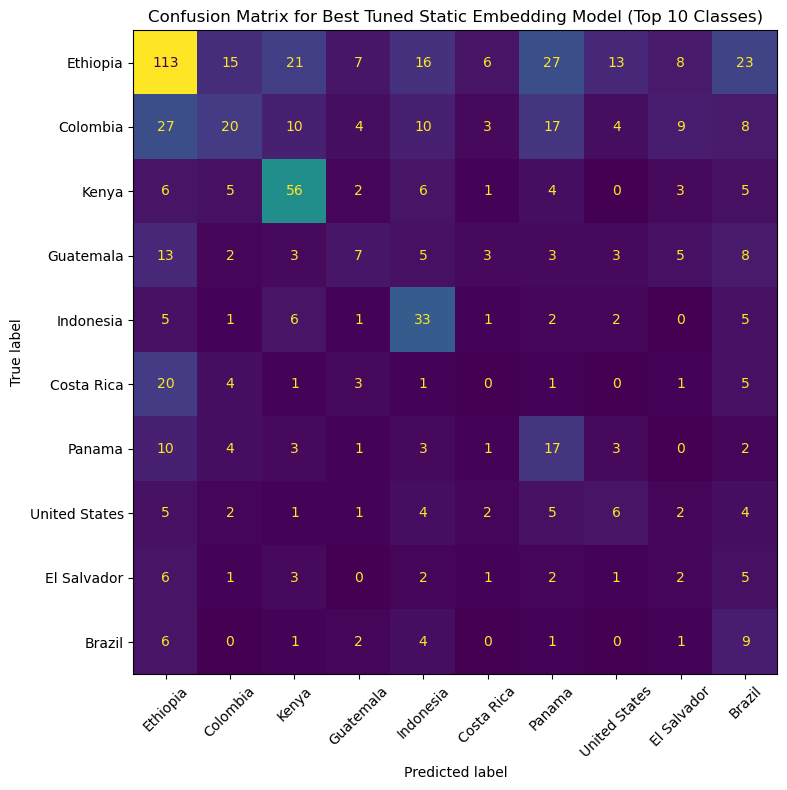

In [13]:
top_confusion_labels = y_test.value_counts().head(10).index
cm = confusion_matrix(y_test, y_test_pred_best, labels=top_confusion_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_confusion_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix for Best Tuned Static Embedding Model (Top 10 Classes)')
plt.tight_layout()
plt.show()

## Training-only resampling experiments

In [14]:
def metric_row_explicit(label, y_val_true, y_val_pred, y_test_true, y_test_pred):
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test_true, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test_true, y_test_pred, average='macro', zero_division=0)

    return {
        'experiment': label,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    }

# Resampling is applied only on the training split to avoid leakage
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train.reset_index(drop=True),
})

max_train_count = train_df['label'].value_counts().max()
min_train_count = train_df['label'].value_counts().min()

oversampled_parts = []
undersampled_parts = []
for label, group in train_df.groupby('label'):
    oversampled_parts.append(group.sample(n=max_train_count, replace=True, random_state=RANDOM_STATE))
    undersampled_parts.append(group.sample(n=min_train_count, replace=False, random_state=RANDOM_STATE))

train_over = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
train_under = pd.concat(undersampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Original training rows:', len(train_df))
print('Oversampled training rows:', len(train_over))
print('Undersampled training rows:', len(train_under))

Original training rows: 4774
Oversampled training rows: 20955
Undersampled training rows: 1065


In [15]:
def train_and_predict_for_resampling(train_texts, train_labels, val_texts, test_texts, params):
    vectors = vectorize_embedding_split(params['embedding_name'], train_texts, val_texts, test_texts)
    X_train_vec, X_val_vec, X_test_vec = vectors
    model = build_classifier(params['model_name'], params['C'], params['feature_reduction'])
    model.fit(X_train_vec, train_labels)
    y_val_pred = model.predict(X_val_vec)
    y_test_pred = model.predict(X_test_vec)
    return y_val_pred, y_test_pred

y_val_pred_original, y_test_pred_original = train_and_predict_for_resampling(X_train, y_train, X_val, X_test, best_params)
y_val_pred_over, y_test_pred_over = train_and_predict_for_resampling(train_over['text'].tolist(), train_over['label'], X_val, X_test, best_params)
y_val_pred_under, y_test_pred_under = train_and_predict_for_resampling(train_under['text'].tolist(), train_under['label'], X_val, X_test, best_params)


In [16]:
resampling_results_df = pd.DataFrame([
    metric_row_explicit('Class weighting only', y_val, y_val_pred_original, y_test, y_test_pred_original),
    metric_row_explicit('Class weighting + oversampled training set', y_val, y_val_pred_over, y_test, y_test_pred_over),
    metric_row_explicit('Class weighting + undersampled training set', y_val, y_val_pred_under, y_test, y_test_pred_under),
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

resampling_results_df

,experiment,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Class weighting only,0.245357,0.176138,0.171857,0.176138,0.161057,0.252199,0.180978,0.167794,0.180978,0.159295
1,Class weighting + oversampled training set,0.203324,0.185570,0.162071,0.185570,0.152277,0.179863,0.175516,0.159364,0.175516,0.142794
2,Class weighting + undersampled training set,0.172043,0.150768,0.124694,0.150768,0.119378,0.171065,0.156937,0.128632,0.156937,0.123452
